In [11]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/xpc-team-digit-recognizer/sample_submission.csv
/kaggle/input/xpc-team-digit-recognizer/train.csv
/kaggle/input/xpc-team-digit-recognizer/test.csv


### Chargement des datasets

In [12]:
train = pd.read_csv("/kaggle/input/xpc-team-digit-recognizer/train.csv")
test = pd.read_csv("/kaggle/input/xpc-team-digit-recognizer/test.csv")
sample = pd.read_csv("/kaggle/input/xpc-team-digit-recognizer/sample_submission.csv")


In [13]:
train

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
sample

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
27995,27996,0
27996,27997,0
27997,27998,0
27998,27999,0


### Verification des valeurs manquantes pour chaque fichier

In [16]:
train.isnull().sum().sum() , test.isnull().sum().sum()

(np.int64(0), np.int64(0))

### Separation des donnees
    — variables explicatives X ;
    — variable cible y;
    - X_test


In [17]:
ImageId = test.index

y = train.iloc[:,0]
X = train.iloc[::,1:]
X_test = test

In [18]:
X

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
y

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [20]:
X_test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


###  Diviser le jeu de données en :
    — un ensemble d’apprentissage ; 
    — un ensemble de test.

In [21]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=1)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape

((37800, 784), (4200, 784), (37800,), (4200,), (28000, 784))

### Normalisation les donnees 

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

### Utilisation des methodes 

### MPLClassifier : 
    entraîner un réseau de neurones multicouche afin de résoudre des problèmes de classification.

In [23]:
model = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=300,
    alpha=1e-4,
    solver='adam',
    verbose=10,
    random_state=1
)


In [24]:
model.fit(X_train, y_train)
print("Train accuracy :", model.score(X_train, y_train))
print("Validation accuracy :", model.score(X_val, y_val))

Iteration 1, loss = 0.50615545
Iteration 2, loss = 0.20585643
Iteration 3, loss = 0.15158317
Iteration 4, loss = 0.12019242
Iteration 5, loss = 0.09887358
Iteration 6, loss = 0.08343411
Iteration 7, loss = 0.07057951
Iteration 8, loss = 0.06084449
Iteration 9, loss = 0.05225230
Iteration 10, loss = 0.04522789
Iteration 11, loss = 0.03877095
Iteration 12, loss = 0.03398042
Iteration 13, loss = 0.02955676
Iteration 14, loss = 0.02516991
Iteration 15, loss = 0.02257222
Iteration 16, loss = 0.01950866
Iteration 17, loss = 0.01650077
Iteration 18, loss = 0.01424089
Iteration 19, loss = 0.01266814
Iteration 20, loss = 0.01100863
Iteration 21, loss = 0.00933232
Iteration 22, loss = 0.00828091
Iteration 23, loss = 0.00719796
Iteration 24, loss = 0.00653081
Iteration 25, loss = 0.00550491
Iteration 26, loss = 0.00493322
Iteration 27, loss = 0.00419763
Iteration 28, loss = 0.00371756
Iteration 29, loss = 0.00337233
Iteration 30, loss = 0.00283937
Iteration 31, loss = 0.00261730
Iteration 32, los

### Predire sur l'ensemble de la validation

In [25]:
y_pred = model.predict(X_val)
print(model.score(X_val, y_val))

0.9642857142857143


In [26]:
df_val = pd.DataFrame({'actual_value' : y_val, 'predicted_value ': y_pred})
df_val.reset_index(drop=True, inplace=True)
df_val

,actual_value,predicted_value
0,1,1
1,5,5
2,2,2
3,8,8
4,4,4
...,...,...
4195,0,0
4196,0,0
4197,4,4
4198,0,0


### Prediction sur l'ensemble des test

In [27]:
predictions = model.predict(X_test)
predictions

array([2, 0, 9, ..., 3, 9, 2])

### Preparer la soumission

In [28]:
output = pd.DataFrame({
    'ImageId': ImageId,
    'Label': predictions
})
output.to_csv('submission.csv', index=False)
print("Ta soumission a ete sauvergarde ")

Ta soumission a ete sauvergarde 


### Soumettre

In [29]:
submission = pd.read_csv('submission.csv')
submission

,ImageId,Label
0,0,2
1,1,0
2,2,9
3,3,9
4,4,3
...,...,...
27995,27995,9
27996,27996,7
27997,27997,3
27998,27998,9


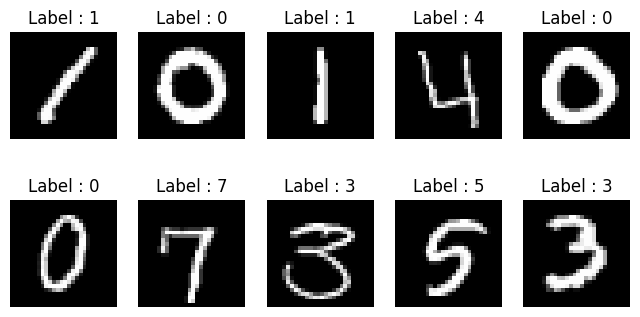

In [30]:
x=train.drop('label',axis=1).values
y=train['label'].values

plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x[i].reshape(28,28),cmap='gray')
    plt.title(f'Label : {y[i]}')
    plt.axis('off')
plt.show()